# pred-2: mining the thread annotations

The 21,803 genuine multi-party exchanges were each turned into one structured
row by an LLM annotator working to a fixed schema (`ANNOTATION_SCHEMA.md`), with
every row validated against a Pydantic model before it reached
`thread_annotations.parquet`. This notebook mines that table: what Enron talked
about, where the executives actually sit, and which conversations carry the asks
and the decisions. The categorical fields come from the model; the per-thread
meta (executive involvement, outcome, message counts) is deterministic from the
cleaned corpus, so the two can be crossed without circularity.

In [1]:
from pathlib import Path
import numpy as np, pandas as pd
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from PIL import Image as _PILImage
from IPython.display import Image as _PNG, display as _show

def find_root() -> Path:
    here = Path.cwd()
    for base in (here, *here.parents):
        if (base / "pred-2" / "thread_annotations.parquet").exists():
            return base
    raise FileNotFoundError("thread_annotations.parquet not found")
ROOT = find_root()
PLOTS = ROOT / "pred-2" / "plots"; PLOTS.mkdir(parents=True, exist_ok=True)

BLUE, RED, ORANGE, GREEN, GREY = "#3b6fb6", "#d04545", "#e08a3c", "#3a7d44", "#b8b8b8"
PURPLE = "#6a3d9a"
pio.templates["enron"] = go.layout.Template(layout=dict(
    font=dict(family="DejaVu Sans, Arial, sans-serif", size=16, color="#222222"),
    title=dict(font=dict(size=23), x=0.5, xanchor="center"),
    paper_bgcolor="white", plot_bgcolor="white",
    xaxis=dict(showgrid=True, gridcolor="#ececec", zeroline=False, linecolor="#bbbbbb",
               ticks="outside", title_font=dict(size=16), tickfont=dict(size=14), automargin=True),
    yaxis=dict(showgrid=True, gridcolor="#ececec", zeroline=False, linecolor="#bbbbbb",
               ticks="outside", title_font=dict(size=16), tickfont=dict(size=14), automargin=True)))
pio.templates.default = "enron"

def save_fig(fig, name, w=1100, h=560, margin=None):
    fig.update_layout(width=w, height=h, margin=margin or dict(l=90, r=70, t=80, b=80))
    out = PLOTS / name
    fig.write_image(out, scale=3)
    _PILImage.open(out).save(out, dpi=(300, 300))
    _show(_PNG(filename=str(out)))
    return fig

df = pd.read_parquet(ROOT / "pred-2" / "thread_annotations.parquet")
PRETTY = {"deal-contract": "Deals & contracts", "internal-admin": "Internal / admin",
    "social": "Social", "trading-risk": "Trading & risk", "scheduling-logistics": "Scheduling",
    "legal-regulatory": "Legal / regulatory", "report-fyi": "Reports / FYI",
    "california-energy": "California crisis"}
print(f"{len(df):,} annotated threads; executives in {df.involves_executive.mean():.0%}, "
      f"a request in {df.has_request.mean():.0%}, a decision in {df.has_decision.mean():.0%}")

21,803 annotated threads; executives in 36%, a request in 73%, a decision in 31%


## What Enron emailed about

Each thread carries one dominant purpose and one outcome. Sorted by volume, the
mix is led by deals and contracts and by internal administration, with the
substantive business categories (deals, the California crisis, legal) the ones
most often left `open`: the captured mailboxes catch those conversations
mid-flight, where social and FYI threads close quickly.

/tmp/ipykernel_473189/1512782602.py:33: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(out, scale=3)


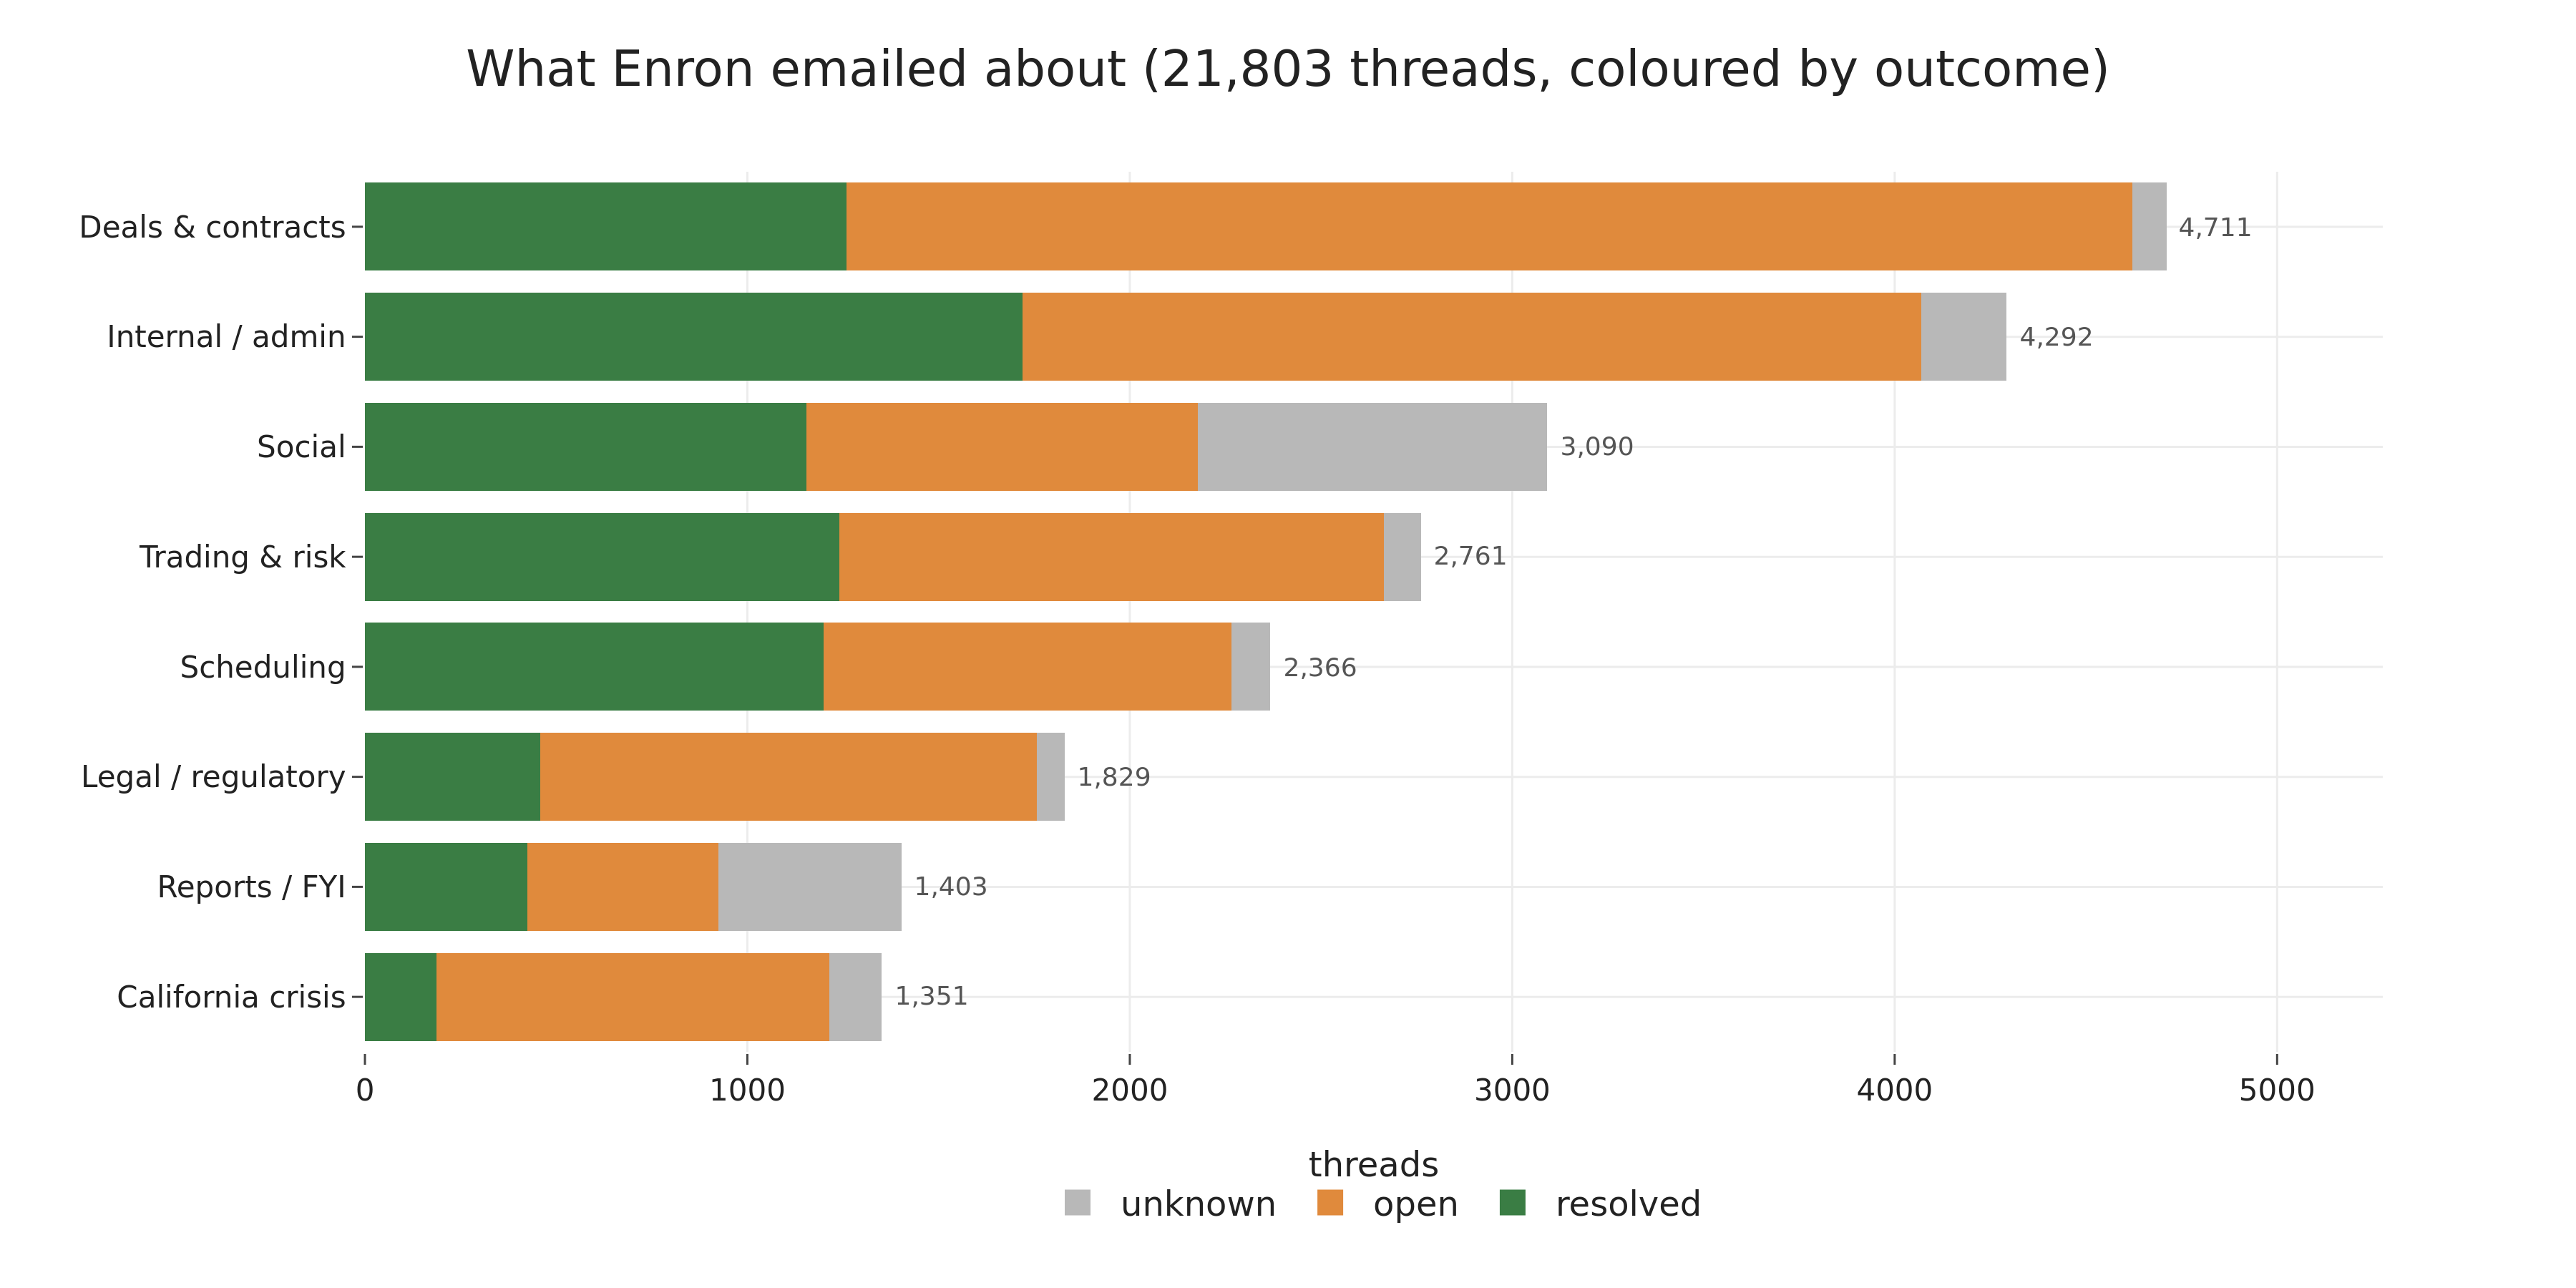

In [2]:
order = df["category"].value_counts().index.tolist()
oc = (df.groupby(["category", "outcome"]).size().unstack(fill_value=0)
        .reindex(order)[["resolved", "open", "unknown"]])
labels = [PRETTY[c] for c in order]
fig = go.Figure()
for outcome, col in [("resolved", GREEN), ("open", ORANGE), ("unknown", GREY)]:
    fig.add_trace(go.Bar(y=labels, x=oc[outcome], name=outcome, orientation="h", marker_color=col))
totals = oc.sum(axis=1)
for i, t in enumerate(totals):
    fig.add_annotation(x=t, y=labels[i], text=f" {t:,}", showarrow=False, xanchor="left",
        font=dict(size=12, color="#555"))
fig.update_yaxes(autorange="reversed")
fig.update_xaxes(title_text="threads", range=[0, totals.max() * 1.12])
fig.update_layout(title="What Enron emailed about (21,803 threads, coloured by outcome)",
    barmode="stack", legend=dict(orientation="h", x=0.5, xanchor="center", y=-0.13, yanchor="top"))
save_fig(fig, "tm1_corpus_composition.png", w=1200, h=600, margin=dict(l=170, r=90, t=80, b=110))

## Where the executives actually sit

Crossing the LLM category with the deterministic executive flag shows a sharp
split. Executives appear in 36% of threads overall, but in nearly three quarters
of the California-crisis threads and roughly half of scheduling and legal ones,
while they turn up in only about a fifth of the deal-contract and trading
threads. The operational deal and trading engine runs below them; the executive
layer lives in the crisis, the regulators and the coordination. This is the
content-side echo of pred-2, where seniority was predictable from metadata: here
it shows up in which conversations a person joins.

/tmp/ipykernel_473189/1512782602.py:33: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(out, scale=3)


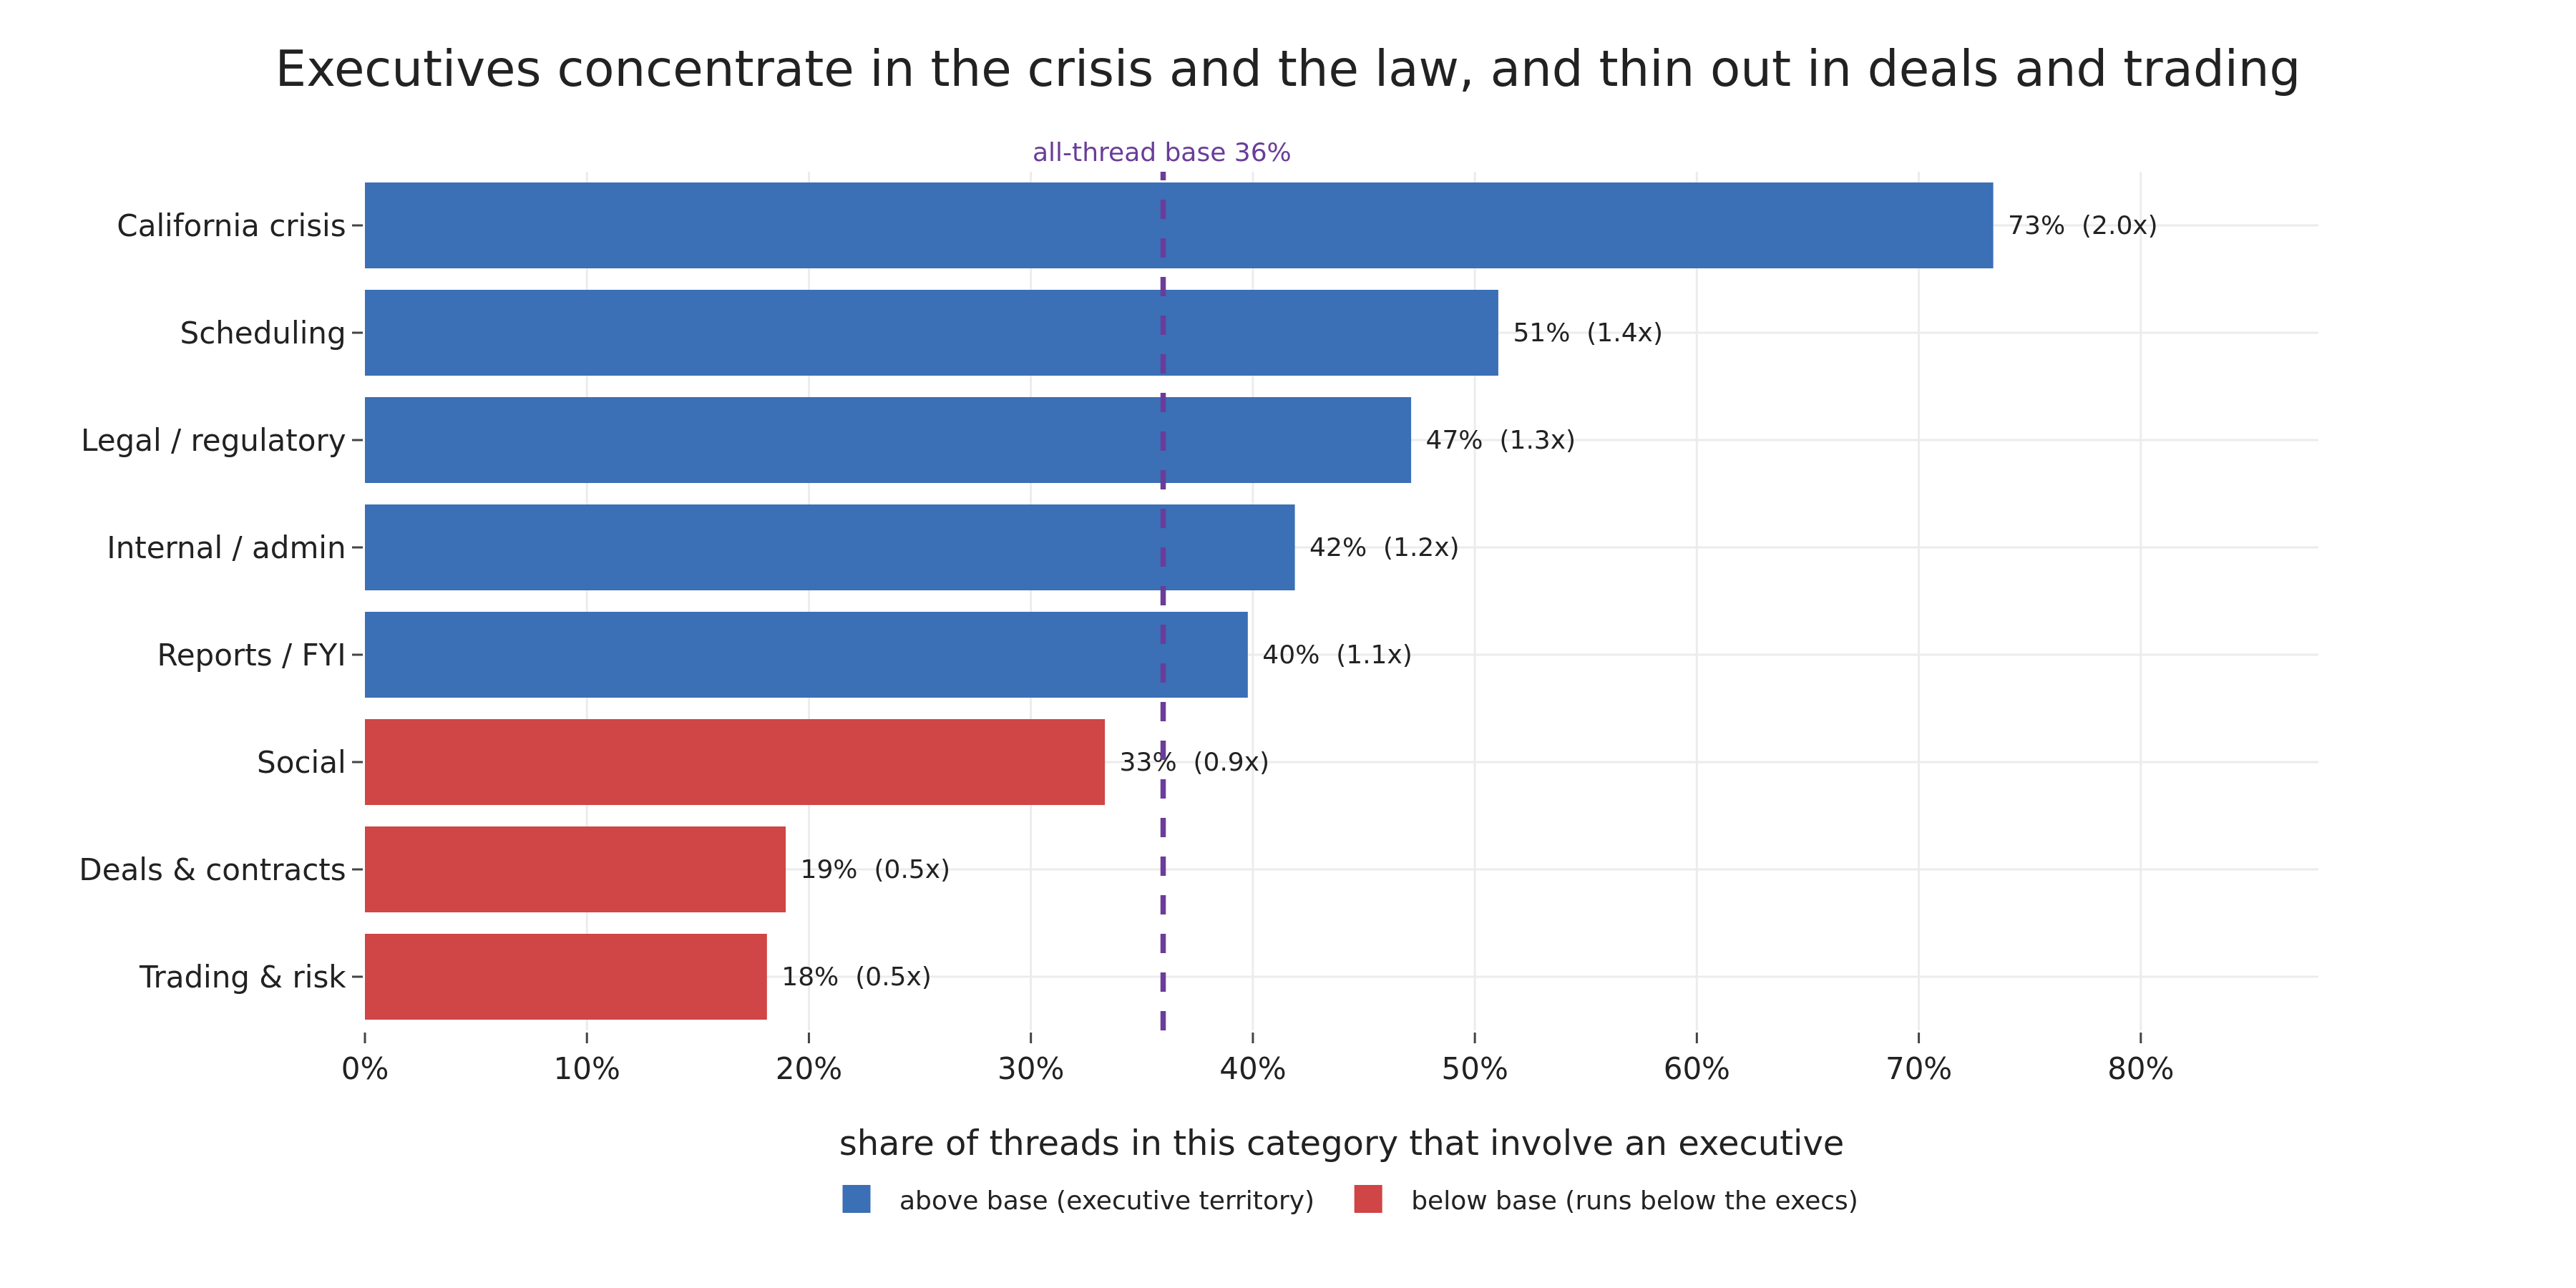

In [3]:
base = df["involves_executive"].mean()
er = df.groupby("category")["involves_executive"].mean().sort_values()
labels = [PRETTY[c] for c in er.index]
cols = [BLUE if v >= base else RED for v in er.values]
fig = go.Figure(go.Bar(y=labels, x=er.values * 100, orientation="h", marker_color=cols,
    text=[f" {v*100:.0f}%  ({v/base:.1f}x)" for v in er.values], textposition="outside",
    textfont=dict(size=12), cliponaxis=False, showlegend=False))
fig.add_vline(x=base * 100, line=dict(color=PURPLE, dash="dash", width=2.5),
    annotation_text=f"all-thread base {base:.0%}", annotation_position="top",
    annotation_font=dict(size=12, color=PURPLE))
for col, nm in [(BLUE, "above base (executive territory)"), (RED, "below base (runs below the execs)")]:
    fig.add_trace(go.Scatter(x=[None], y=[None], mode="markers",
        marker=dict(size=13, color=col, symbol="square"), name=nm))
fig.update_xaxes(title_text="share of threads in this category that involve an executive",
    range=[0, 88], ticksuffix="%")
fig.update_layout(title="Executives concentrate in the crisis and the law, and thin out in deals and trading",
    legend=dict(orientation="h", x=0.5, xanchor="center", y=-0.16, yanchor="top", font=dict(size=12)))
save_fig(fig, "tm2_executives_by_topic.png", w=1200, h=600, margin=dict(l=170, r=120, t=80, b=120))

## Asks and decisions

Almost three quarters of threads contain a request, so the corpus is a working
inbox in its own right. Decisions are rarer and concentrate in the
operational categories: scheduling, trading and deals carry the most decided
or explicitly deferred conversations, while reports and social threads are
mostly one-directional.

/tmp/ipykernel_473189/1512782602.py:33: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(out, scale=3)


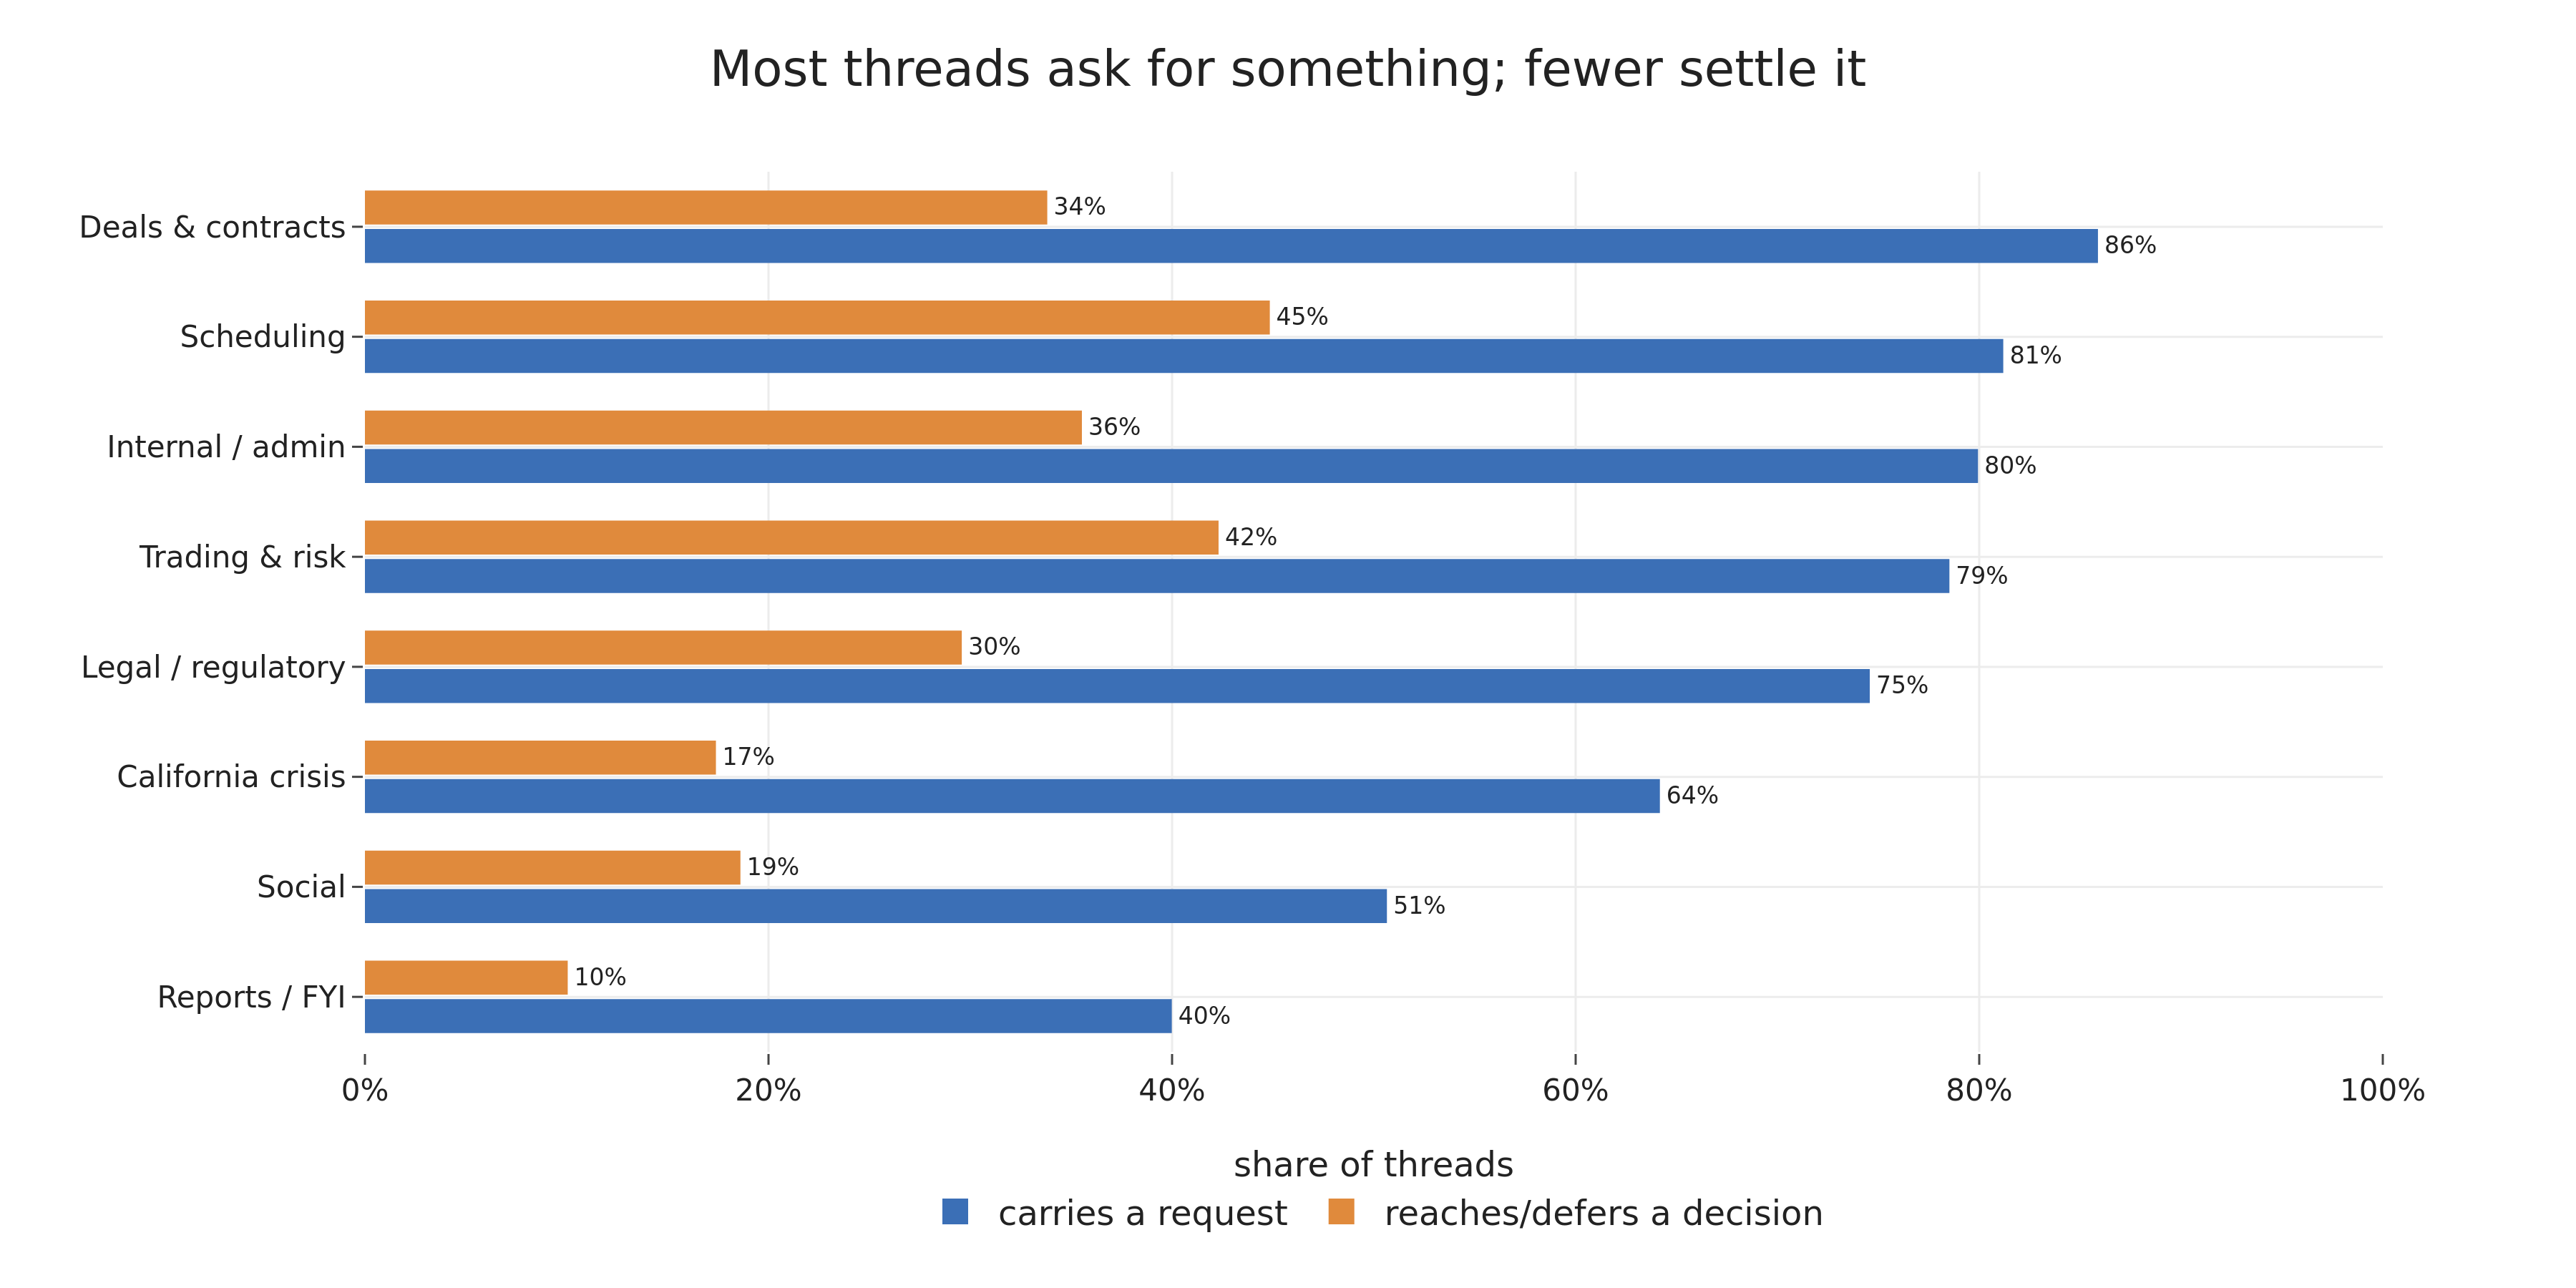

In [4]:
act = df.groupby("category").agg(req=("has_request", "mean"), dec=("has_decision", "mean"))
act = act.sort_values("req")
labels = [PRETTY[c] for c in act.index]
fig = go.Figure()
fig.add_trace(go.Bar(y=labels, x=act["req"] * 100, orientation="h", marker_color=BLUE,
    name="carries a request", text=[f"{v*100:.0f}%" for v in act["req"]], textposition="outside",
    textfont=dict(size=11), cliponaxis=False))
fig.add_trace(go.Bar(y=labels, x=act["dec"] * 100, orientation="h", marker_color=ORANGE,
    name="reaches/defers a decision", text=[f"{v*100:.0f}%" for v in act["dec"]], textposition="outside",
    textfont=dict(size=11), cliponaxis=False))
fig.update_xaxes(title_text="share of threads", range=[0, 100], ticksuffix="%")
fig.update_layout(title="Most threads ask for something; fewer settle it",
    barmode="group", bargap=0.3, bargroupgap=0.12,
    legend=dict(orientation="h", x=0.5, xanchor="center", y=-0.14, yanchor="top"))
save_fig(fig, "tm3_requests_decisions.png", w=1200, h=600, margin=dict(l=170, r=90, t=80, b=110))

## The arc of the collapse

Each thread carries a date, so the category mix can be tracked month by month.
Across 2000 to 2002 it traces the company itself: deal-making shrinks while
internal administration and social mail climb, and the lines cross around the
December 2001 bankruptcy. The mail turns from making deals to winding the place
down and saying goodbye.

/tmp/ipykernel_473189/1512782602.py:33: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(out, scale=3)


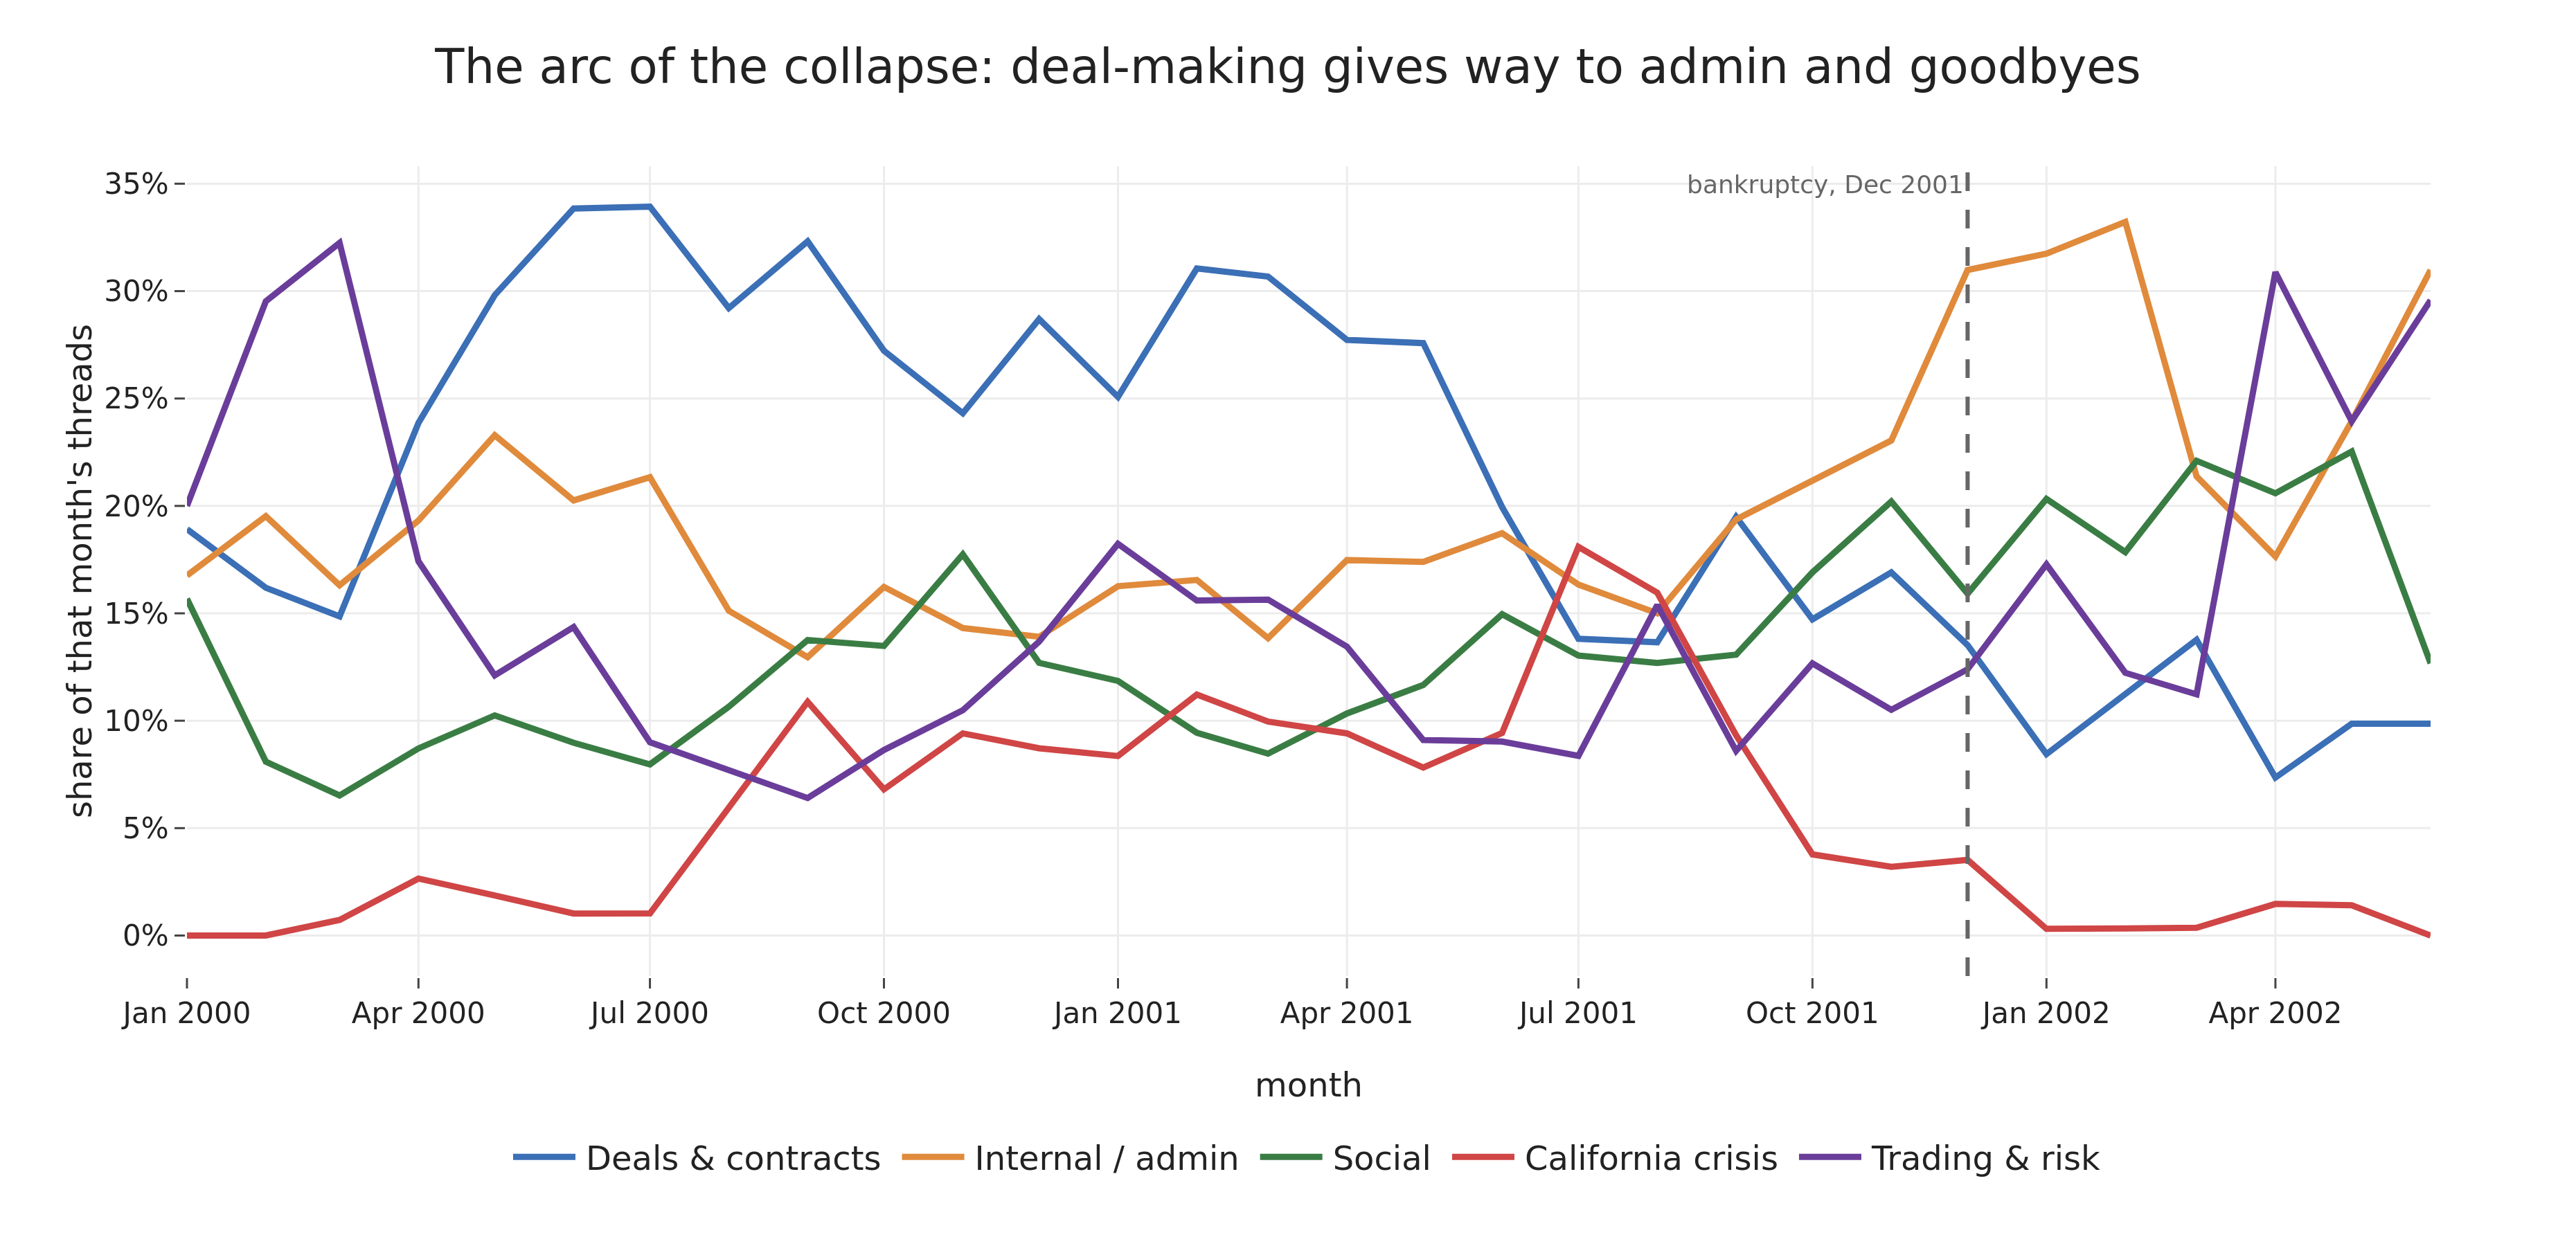

In [5]:
d = df.copy()
d["month"] = pd.to_datetime(d["date"], errors="coerce").dt.to_period("M").dt.to_timestamp()
d = d[(d["month"] >= "2000-01-01") & (d["month"] <= "2002-06-01")]
vol = d.groupby("month").size()
share = (pd.crosstab(d["month"], d["category"], normalize="index") * 100).loc[vol[vol >= 40].index]
KEY = ["deal-contract", "internal-admin", "social", "california-energy", "trading-risk"]
COL = {"deal-contract": BLUE, "internal-admin": ORANGE, "social": GREEN,
       "california-energy": RED, "trading-risk": PURPLE}
fig = go.Figure()
for c in KEY:
    fig.add_trace(go.Scatter(x=share.index, y=share[c], mode="lines", name=PRETTY[c],
        line=dict(color=COL[c], width=3)))
fig.add_vline(x="2001-12-01", line=dict(color="#666", dash="dash", width=2),
    annotation_text="bankruptcy, Dec 2001", annotation_position="top left",
    annotation_font=dict(size=12, color="#666"))
fig.update_xaxes(title_text="month")
fig.update_yaxes(title_text="share of that month's threads", ticksuffix="%")
fig.update_layout(title="The arc of the collapse: deal-making gives way to admin and goodbyes",
    legend=dict(orientation="h", x=0.5, xanchor="center", y=-0.18, yanchor="top"))
save_fig(fig, "tm4_category_arc.png", w=1240, h=600, margin=dict(l=90, r=70, t=80, b=130))

## Enron's world, extracted

The annotator pulled named entities from every thread, 33,078 distinct names in
all. The most frequent ones name the corpus's subject matter directly: the
regulators it answered to, the counterparties it traded with, and its own desks
and systems.

/tmp/ipykernel_473189/1512782602.py:33: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(out, scale=3)


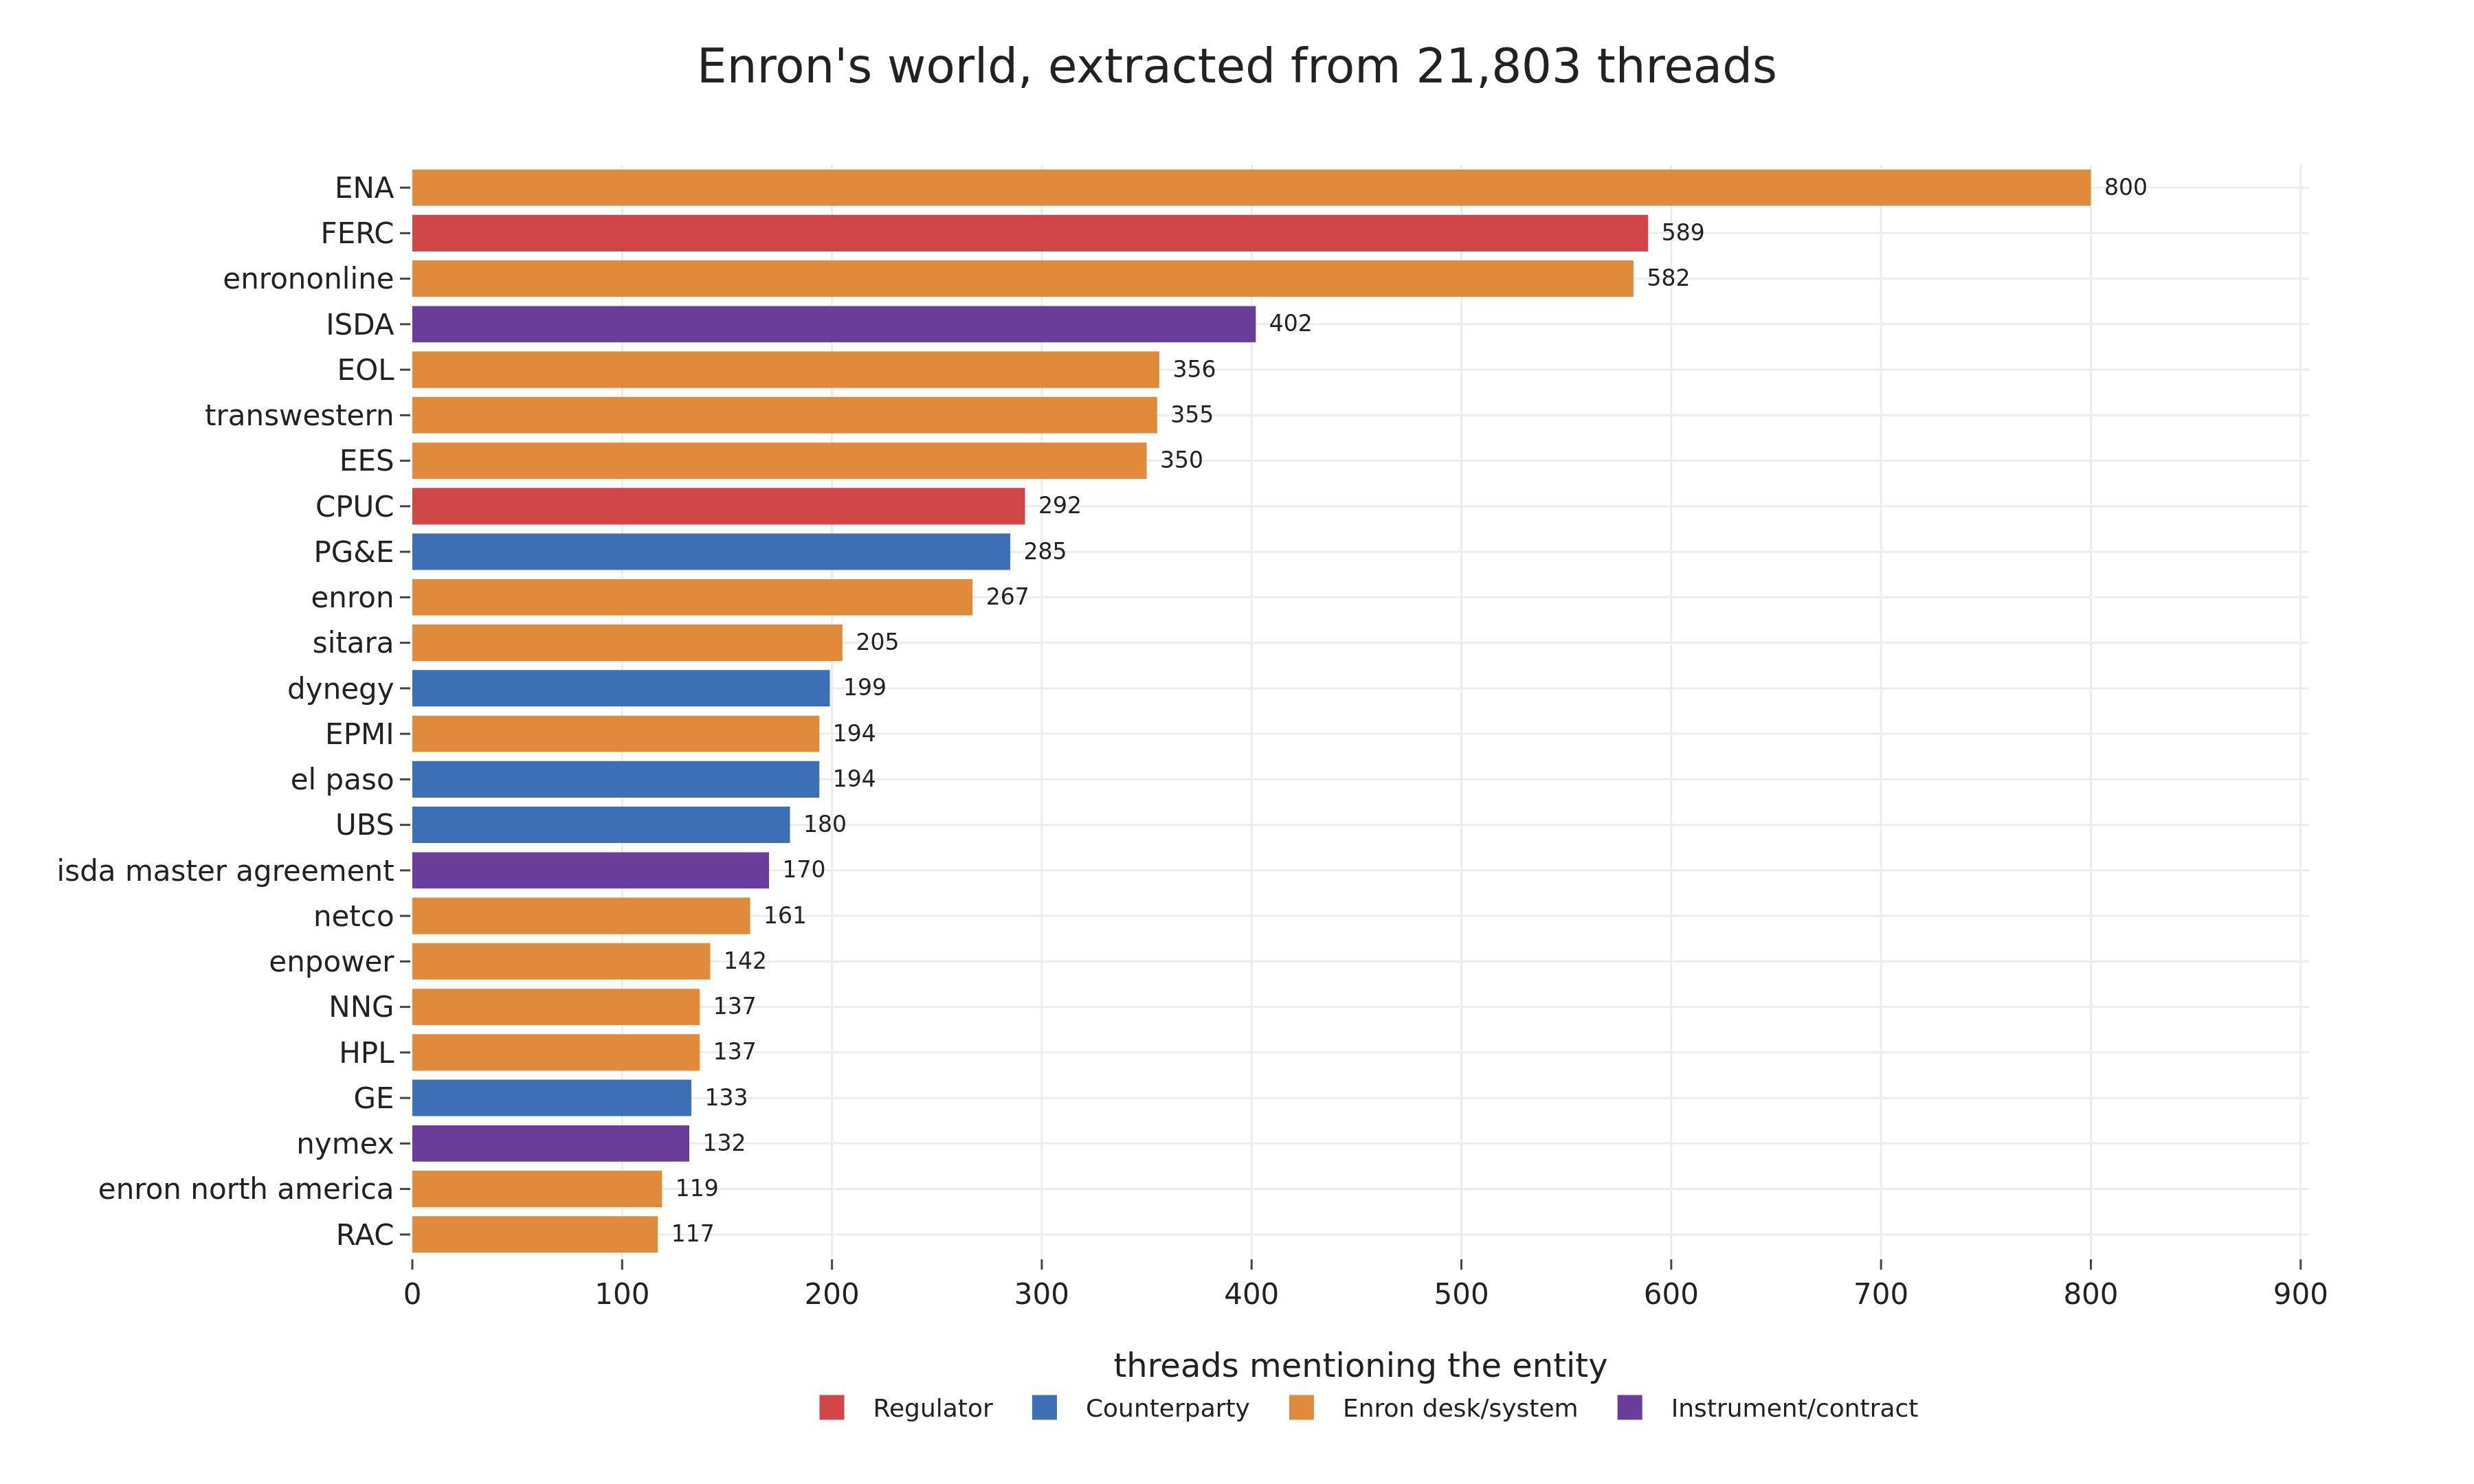

In [6]:
import json, collections
cnt = collections.Counter()
for s in df["entities"].dropna():
    try:
        for e in json.loads(s):
            e = str(e).strip().lower()
            if e:
                cnt[e] += 1
    except Exception:
        pass
TYPE = {
    "ferc": "Regulator", "cpuc": "Regulator", "california": "Regulator", "calpx": "Regulator",
    "caiso": "Regulator", "cal-iso": "Regulator", "ercot": "Regulator",
    "dynegy": "Counterparty", "pg&e": "Counterparty", "el paso": "Counterparty", "sce": "Counterparty",
    "aep": "Counterparty", "ubs": "Counterparty", "ge": "Counterparty", "prebon": "Counterparty",
    "ena": "Enron desk/system", "enrononline": "Enron desk/system", "eol": "Enron desk/system",
    "ees": "Enron desk/system", "epmi": "Enron desk/system", "sitara": "Enron desk/system",
    "netco": "Enron desk/system", "enpower": "Enron desk/system", "nng": "Enron desk/system",
    "hpl": "Enron desk/system", "transwestern": "Enron desk/system", "enron": "Enron desk/system",
    "enron north america": "Enron desk/system", "rac": "Enron desk/system",
    "isda": "Instrument/contract", "isda master agreement": "Instrument/contract",
    "master agreement": "Instrument/contract", "nymex": "Instrument/contract", "direct access": "Instrument/contract",
}
TCOL = {"Regulator": RED, "Counterparty": BLUE, "Enron desk/system": ORANGE,
        "Instrument/contract": PURPLE, "Other": GREY}
top = cnt.most_common(24)[::-1]
names = [e for e, _ in top]; vals = [n for _, n in top]
types = [TYPE.get(e, "Other") for e in names]
labels = [e.upper() if len(e) <= 4 else e for e in names]
fig = go.Figure(go.Bar(y=labels, x=vals, orientation="h", marker_color=[TCOL[t] for t in types],
    text=[f" {v}" for v in vals], textposition="outside", textfont=dict(size=11),
    cliponaxis=False, showlegend=False))
for t, c in TCOL.items():
    if t in types:
        fig.add_trace(go.Scatter(x=[None], y=[None], mode="markers",
            marker=dict(size=12, color=c, symbol="square"), name=t))
fig.update_xaxes(title_text="threads mentioning the entity", range=[0, max(vals) * 1.13])
fig.update_layout(title=f"Enron's world, extracted from {len(df):,} threads",
    legend=dict(orientation="h", x=0.5, xanchor="center", y=-0.11, yanchor="top", font=dict(size=12)))
save_fig(fig, "tm5_entity_landscape.png", w=1200, h=720, margin=dict(l=200, r=80, t=80, b=110))

## What you discuss reveals your rank

pred-2 predicted executive status from how a person emails. The annotations give
a second, independent view: the mix of conversation categories a person takes
part in. Built per owner and scored leave-some-out, that content signature places
an executive at AUC 0.73 (permutation null around 0.50, p about 0.003), close
behind the 0.80 from metadata. The weights say executives lean toward legal,
reports and coordination and lean away from the trading desk.

content AUC 0.729 on 135 owners (40 executives)


/tmp/ipykernel_473189/1512782602.py:33: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(out, scale=3)


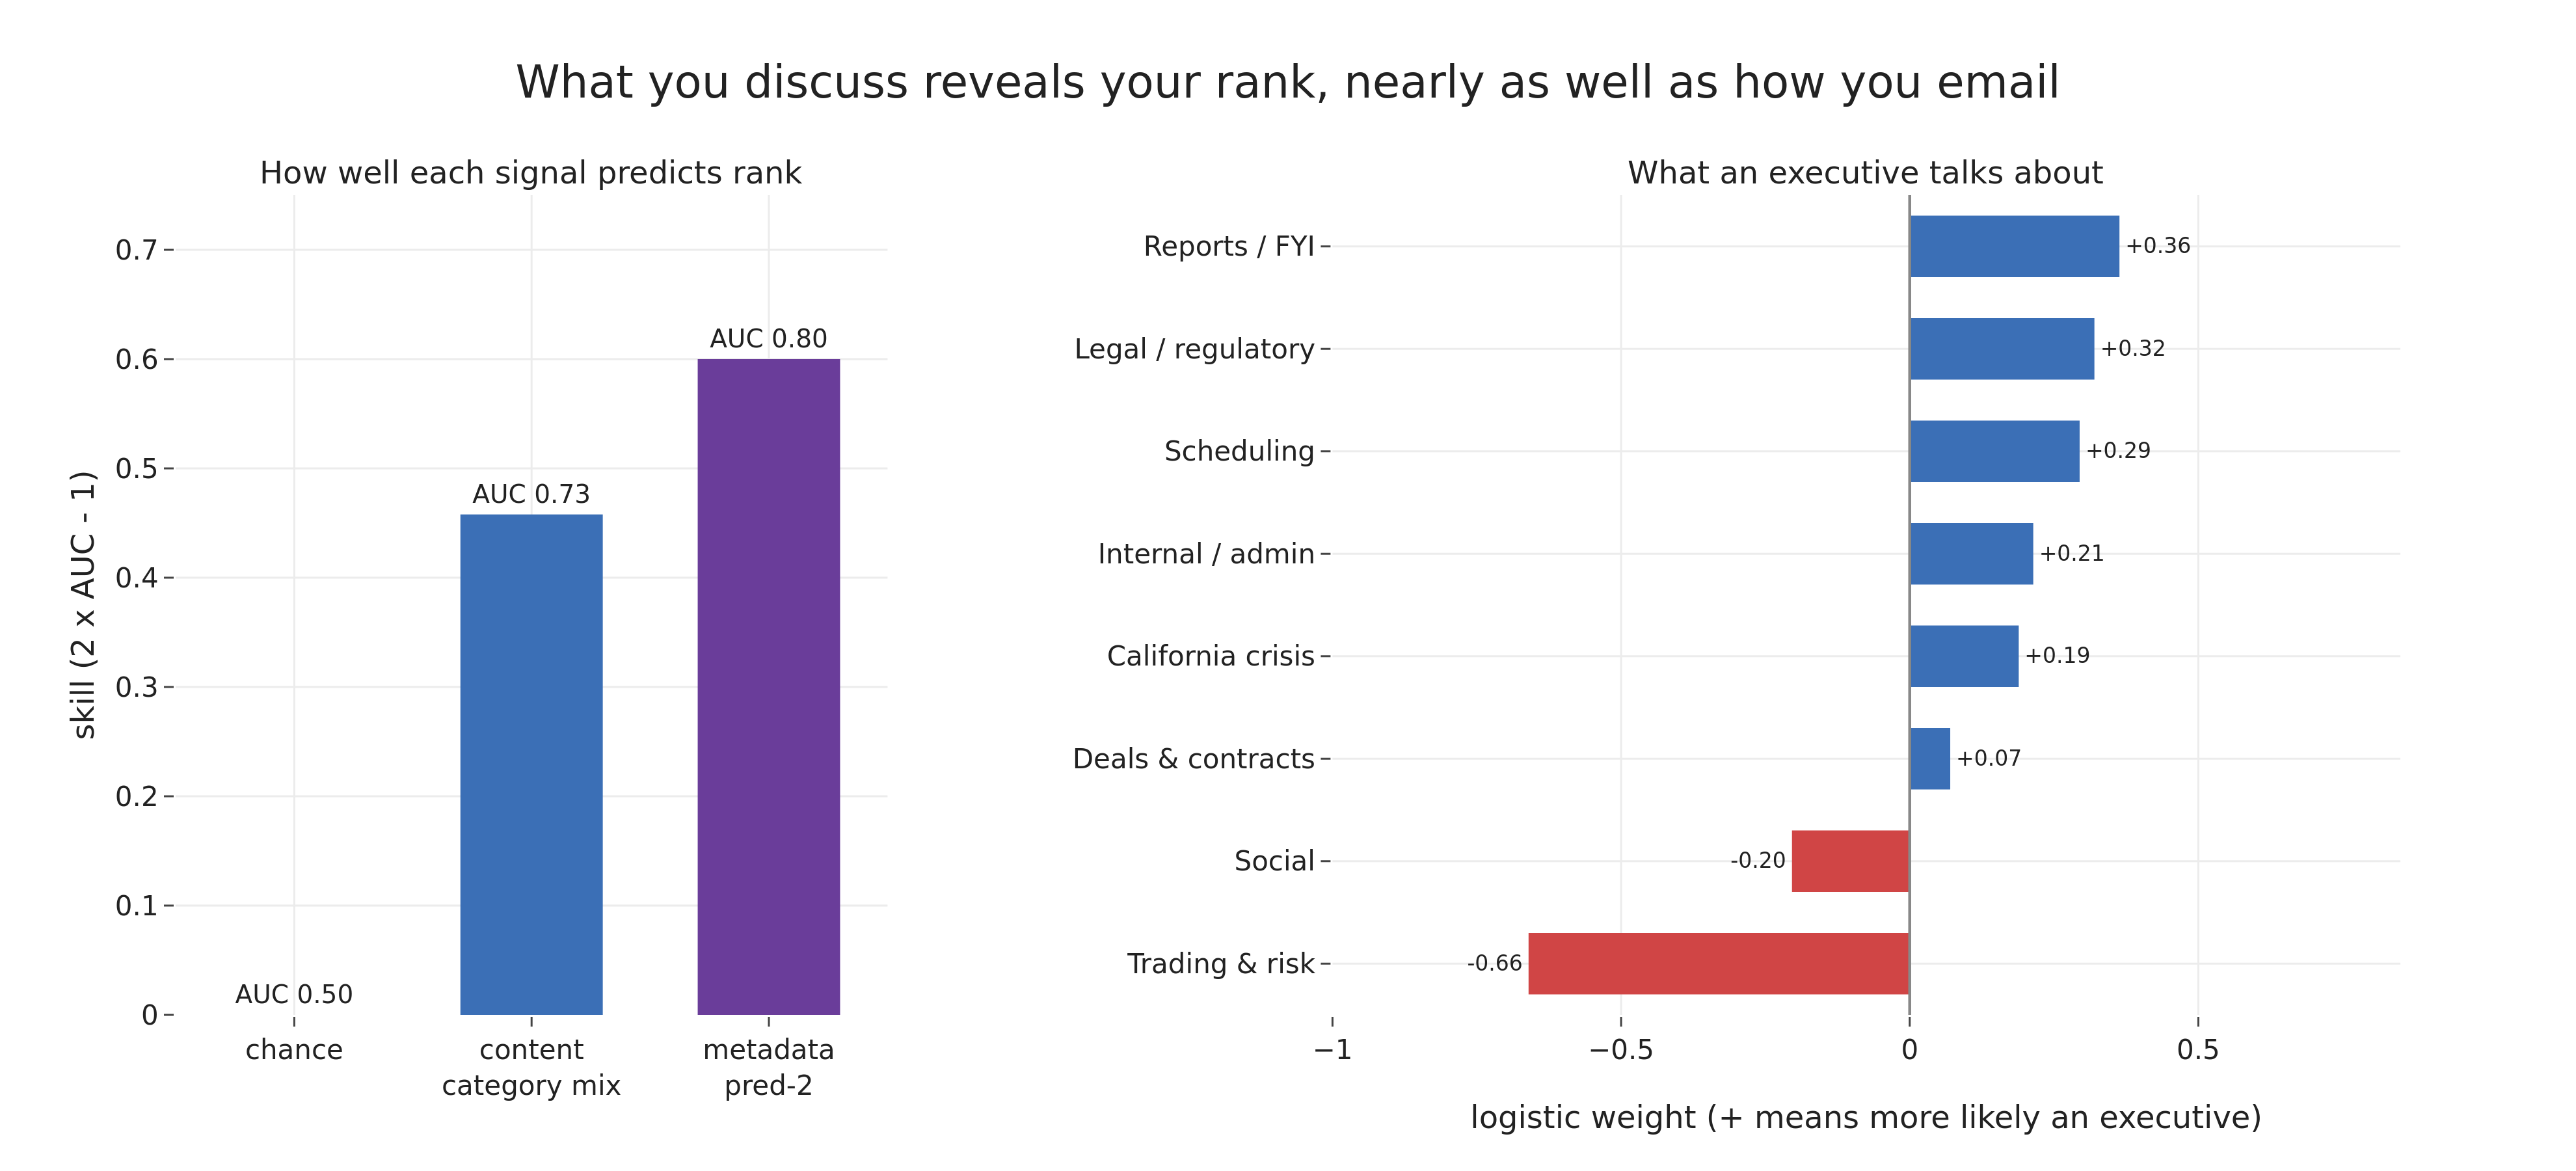

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score
CLEAN = ROOT / "eda-5" / "clean"; REFS = ROOT / "eda-5" / "refs"
msg = pd.read_parquet(CLEAN / "messages_clean.parquet", columns=["thread_id", "sender_person", "from_addr_norm"])
roles = pd.read_parquet(CLEAN / "people_roles.parquet").set_index("owner")
DEL = set(pd.read_csv(REFS / "assistant_delegates.csv", sep=";")["assistant_addr"])
au = msg[msg.sender_person.notna() & ~msg.from_addr_norm.isin(DEL)]
keep = set(au.groupby("sender_person").size().pipe(lambda s: s[s >= 30]).index)
j = au[au.sender_person.isin(keep)].merge(df[["thread_id", "category"]], on="thread_id")
mix = pd.crosstab(j.sender_person, j.category, normalize="index")
nthr = j.groupby("sender_person").thread_id.nunique()
mix = mix.loc[nthr[nthr >= 10].index]
CATS = list(mix.columns); X = mix.values
y = roles["is_executive"].reindex(mix.index).astype(int).values
clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, class_weight="balanced"))
cv = StratifiedKFold(10, shuffle=True, random_state=0)
auc = roc_auc_score(y, cross_val_predict(clf, X, y, cv=cv, method="predict_proba")[:, 1])
coef = pd.Series(LogisticRegression(max_iter=5000, class_weight="balanced")
                 .fit(StandardScaler().fit_transform(X), y).coef_[0], index=CATS).sort_values()
print(f"content AUC {auc:.3f} on {len(mix)} owners ({int(y.sum())} executives)")

fig = make_subplots(rows=1, cols=2, column_widths=[0.4, 0.6], horizontal_spacing=0.2,
    subplot_titles=["How well each signal predicts rank", "What an executive talks about"])
gini = [("chance", 0.0, GREY), ("content<br>category mix", 2 * auc - 1, BLUE),
        ("metadata<br>pred-2", 2 * 0.80 - 1, PURPLE)]
fig.add_trace(go.Bar(x=[g[0] for g in gini], y=[g[1] for g in gini], marker_color=[g[2] for g in gini],
    text=[f"AUC {0.5 + g[1] / 2:.2f}" for g in gini], textposition="outside", textfont=dict(size=13),
    cliponaxis=False, showlegend=False), row=1, col=1)
fig.update_yaxes(title_text="skill (2 x AUC - 1)", range=[0, 0.75], row=1, col=1)
fig.add_trace(go.Bar(y=[PRETTY[c] for c in coef.index], x=coef.values, orientation="h",
    marker_color=[RED if v < 0 else BLUE for v in coef.values],
    text=[f"{v:+.2f}" for v in coef.values], textposition="outside", textfont=dict(size=11),
    cliponaxis=False, showlegend=False), row=1, col=2)
fig.add_vline(x=0, line=dict(color="#888", width=1.5), row=1, col=2)
fig.update_xaxes(title_text="logistic weight (+ means more likely an executive)", range=[-1.0, 0.85], row=1, col=2)
fig.update_layout(title="What you discuss reveals your rank, nearly as well as how you email", bargap=0.4)
save_fig(fig, "tm6_content_seniority.png", w=1320, h=600, margin=dict(l=90, r=90, t=100, b=80))

## What the annotations add

The annotation layer gives a content map the metadata alone could not provide.
Enron's mail is a working inbox where executives concentrate in the crisis and
the law, the category mix shifts from deal-making in 2000 toward administration
and farewells by 2002, and the extracted entities lay out the regulators,
counterparties and desks the corpus revolves around. The mix of topics a person
works in predicts their rank at AUC 0.73 on its own, so fusing that content
signature with the pred-2 metadata is the natural next step.